In [1]:
import numpy as np
from glob import glob
import tensorflow as tf
from tensorflow import keras
from keras_unet_collection import models, utils
import os
import segmentation_models as sm
from segmentation_models import Unet
import matplotlib.pyplot as plt

2024-01-16 10:08:51.367718: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-01-16 10:08:51.372273: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /share/home/zju_fangjb/opt/ImageMagick/lib:/share/home/zju_fangjb/opt/lib:/share/home/zju_fangjb/opt/openbabel/lib:/share/home/zju_fangjb/opt/orca:/share/home/zju_fangjb/opt/openmpi/lib:/share/home/zju_fangjb/opt/gaussian/g16/bsd:/share/home/zju_fangjb/opt/gaussian/g16:/share/home/zju_fangjb/.conda/envs/uvvisml/lib:/share/home/zju_fangjb/opt/ImageMagick/lib:/share/home/zju_fangjb/opt/lib:/share/home/zju_fangjb/opt/openbabel/lib:/share/home/zju_fangjb/opt

Segmentation Models: using `keras` framework.


In [2]:
from tensorflow.keras.optimizers import Adam
import tensorflow.keras
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import AveragePooling2D, Flatten
from keras.layers import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model

In [3]:
x_train = np.load('./MMHID/MMHID-train/MMHID-train-G-imgs.npy')
y_train = np.load('./MMHID/MMHID-train/MMHID-train-G-labels.npy')
x_test = np.load('./MMHID/MMHID-test/MMHID-test-G-imgs.npy')
y_test = np.load('./MHID/MMHID-test/MMHID-test-G-labels.npy')

In [4]:
keras.backend.set_image_data_format('channels_last')

In [5]:
model = Unet(backbone_name='efficientnetb0', encoder_weights=None, input_shape=(512, 512, 3))

2024-01-16 10:09:26.745069: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /share/home/zju_fangjb/opt/ImageMagick/lib:/share/home/zju_fangjb/opt/lib:/share/home/zju_fangjb/opt/openbabel/lib:/share/home/zju_fangjb/opt/orca:/share/home/zju_fangjb/opt/openmpi/lib:/share/home/zju_fangjb/opt/gaussian/g16/bsd:/share/home/zju_fangjb/opt/gaussian/g16:/share/home/zju_fangjb/.conda/envs/uvvisml/lib:/share/home/zju_fangjb/opt/ImageMagick/lib:/share/home/zju_fangjb/opt/lib:/share/home/zju_fangjb/opt/openbabel/lib:/share/home/zju_fangjb/opt/orca:/share/home/zju_fangjb/opt/openmpi/lib:/share/home/zju_fangjb/opt/gaussian/g16/bsd:/share/home/zju_fangjb/opt/gaussian/g16:/.singularity.d/libs:/share/home/zju_fangjb/opt/gaussian/gv/lib:/share/home/zju_fangjb/opt/gaussian/gv/lib
2024-01-16 10:09:26.745123: W tensorflow/stream_executor/cuda/cuda_d

In [6]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 stem_conv (Conv2D)             (None, 256, 256, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 stem_bn (BatchNormalization)   (None, 256, 256, 32  128         ['stem_conv[0][0]']              
                                )                                                             

                                                                                                  
 block2b_expand_activation (Act  (None, 128, 128, 14  0          ['block2b_expand_bn[0][0]']      
 ivation)                       4)                                                                
                                                                                                  
 block2b_dwconv (DepthwiseConv2  (None, 128, 128, 14  1296       ['block2b_expand_activation[0][0]
 D)                             4)                               ']                               
                                                                                                  
 block2b_bn (BatchNormalization  (None, 128, 128, 14  576        ['block2b_dwconv[0][0]']         
 )                              4)                                                                
                                                                                                  
 block2b_a

 block3b_bn (BatchNormalization  (None, 64, 64, 240)  960        ['block3b_dwconv[0][0]']         
 )                                                                                                
                                                                                                  
 block3b_activation (Activation  (None, 64, 64, 240)  0          ['block3b_bn[0][0]']             
 )                                                                                                
                                                                                                  
 block3b_se_squeeze (GlobalAver  (None, 240)         0           ['block3b_activation[0][0]']     
 agePooling2D)                                                                                    
                                                                                                  
 block3b_se_reshape (Reshape)   (None, 1, 1, 240)    0           ['block3b_se_squeeze[0][0]']     
          

                                                                                                  
 block4b_se_reduce (Conv2D)     (None, 1, 1, 20)     9620        ['block4b_se_reshape[0][0]']     
                                                                                                  
 block4b_se_expand (Conv2D)     (None, 1, 1, 480)    10080       ['block4b_se_reduce[0][0]']      
                                                                                                  
 block4b_se_excite (Multiply)   (None, 32, 32, 480)  0           ['block4b_activation[0][0]',     
                                                                  'block4b_se_expand[0][0]']      
                                                                                                  
 block4b_project_conv (Conv2D)  (None, 32, 32, 80)   38400       ['block4b_se_excite[0][0]']      
                                                                                                  
 block4b_p

 block5a_se_excite (Multiply)   (None, 32, 32, 480)  0           ['block5a_activation[0][0]',     
                                                                  'block5a_se_expand[0][0]']      
                                                                                                  
 block5a_project_conv (Conv2D)  (None, 32, 32, 112)  53760       ['block5a_se_excite[0][0]']      
                                                                                                  
 block5a_project_bn (BatchNorma  (None, 32, 32, 112)  448        ['block5a_project_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 block5b_expand_conv (Conv2D)   (None, 32, 32, 672)  75264       ['block5a_project_bn[0][0]']     
                                                                                                  
 block5b_e

 block5c_add (Add)              (None, 32, 32, 112)  0           ['block5c_drop[0][0]',           
                                                                  'block5b_add[0][0]']            
                                                                                                  
 block6a_expand_conv (Conv2D)   (None, 32, 32, 672)  75264       ['block5c_add[0][0]']            
                                                                                                  
 block6a_expand_bn (BatchNormal  (None, 32, 32, 672)  2688       ['block6a_expand_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 block6a_expand_activation (Act  (None, 32, 32, 672)  0          ['block6a_expand_bn[0][0]']      
 ivation)                                                                                         
          

 block6c_expand_activation (Act  (None, 16, 16, 1152  0          ['block6c_expand_bn[0][0]']      
 ivation)                       )                                                                 
                                                                                                  
 block6c_dwconv (DepthwiseConv2  (None, 16, 16, 1152  28800      ['block6c_expand_activation[0][0]
 D)                             )                                ']                               
                                                                                                  
 block6c_bn (BatchNormalization  (None, 16, 16, 1152  4608       ['block6c_dwconv[0][0]']         
 )                              )                                                                 
                                                                                                  
 block6c_activation (Activation  (None, 16, 16, 1152  0          ['block6c_bn[0][0]']             
 )        

 block7a_dwconv (DepthwiseConv2  (None, 16, 16, 1152  10368      ['block7a_expand_activation[0][0]
 D)                             )                                ']                               
                                                                                                  
 block7a_bn (BatchNormalization  (None, 16, 16, 1152  4608       ['block7a_dwconv[0][0]']         
 )                              )                                                                 
                                                                                                  
 block7a_activation (Activation  (None, 16, 16, 1152  0          ['block7a_bn[0][0]']             
 )                              )                                                                 
                                                                                                  
 block7a_se_squeeze (GlobalAver  (None, 1152)        0           ['block7a_activation[0][0]']     
 agePoolin

 decoder_stage2_upsampling (UpS  (None, 128, 128, 12  0          ['decoder_stage1b_relu[0][0]']   
 ampling2D)                     8)                                                                
                                                                                                  
 decoder_stage2_concat (Concate  (None, 128, 128, 27  0          ['decoder_stage2_upsampling[0][0]
 nate)                          2)                               ',                               
                                                                  'block3a_expand_activation[0][0]
                                                                 ']                               
                                                                                                  
 decoder_stage2a_conv (Conv2D)  (None, 128, 128, 64  156672      ['decoder_stage2_concat[0][0]']  
                                )                                                                 
          

In [7]:
logdir = "ModelWeights/"
if not os.path.exists(logdir):
    os.mkdir(logdir)
    
output_model_file = os.path.join(logdir,'./G_Unet4_efficientnetb0_0116.hdf5')

In [9]:
def lr_schedule(epoch):
    lr = 1e-3
    print('Learning rate: ', lr)
    return lr

In [10]:
tensorboard = keras.callbacks.TensorBoard(logdir)
checkpoint = ModelCheckpoint(filepath=output_model_file,
                             monitor='loss',
                             verbose=1,
                             save_best_only=True)

lr_scheduler = LearningRateScheduler(lr_schedule)
lr_reducer = ReduceLROnPlateau(factor=np.sqrt(0.1),
                               cooldown=0,
                               patience=5,
                               min_lr=0.5e-6)

callbacks = [tensorboard, checkpoint, lr_reducer, lr_scheduler]#

In [11]:
model.compile(
    optimizer=Adam(learning_rate=lr_schedule(0)),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)


Learning rate:  0.001


In [ ]:
history=model.fit(
   x=x_train,
   y=y_train,
   batch_size=50,
   epochs=100,
   validation_split=0.4,
    callbacks=callbacks
)

In [27]:
model.load_weights(output_model_file)

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
test = model.predict(x_test, batch_size=1, verbose=1)

In [ ]:
model.evaluate(x_test,y_test)

In [31]:
from medpy import metric

def calculate_metric_percase(pred, gt):
    dice = metric.binary.dc(pred, gt)
    jc = metric.binary.jc(pred, gt)
    hd = metric.binary.hd95(pred, gt)
    asd = metric.binary.asd(pred, gt)
    return dice, jc, hd, asd


In [ ]:
calculate_metric_percase(test, y_test)

In [ ]:
test[test>0.5]=1
test[test<0.5]=0

In [ ]:
calculate_metric_percase(test, y_test)

In [35]:
i=5

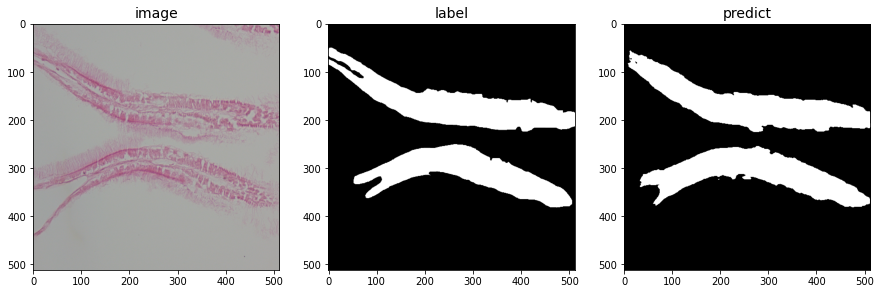

In [36]:
fig, axs = plt.subplots(1,3,figsize=(15,15))
axs[0].imshow(x_test[i], cmap ='gray')
axs[1].imshow(y_test[i], cmap ='gray')
axs[2].imshow(test[i], cmap ='gray')
axs[0].set_title("image",fontsize=14)
axs[1].set_title("label",fontsize=14)
axs[2].set_title("predict",fontsize=14)
plt.grid(False)

In [ ]:
test1 = tf.compat.v1.image.resize_images(test,(3000,4000))
test1.shape